# Reproducing Henrich (2004): Demography and Cultural Evolution

Based on a gemini chat 12/24/25

This notebook reproduces the core mathematical arguments and figures from Joseph Henrich's paper *"Demography and Cultural Evolution: How Adaptive Cultural Processes Can Produce Maladaptive Losses - The Tasmanian Case"* (American Antiquity, 2004).

## The Core Model
The paper argues that complex skills are maintained by a process of imperfect social learning.
* **Inaccurate Learning ($\alpha$):** Most learners will not be as good as the person they copy.
* **Variation ($\beta$):** Occasionally, a learner is "lucky" or talented and improves on the technique.
* **Selection ($N$):** A larger population ($N$) increases the chances of finding a "lucky" learner who exceeds the current skill ceiling, preventing the technology from degrading.

The change in average skill ($\Delta \bar{z}$) is derived in the paper as:

$$
\Delta \bar{z} = -\alpha + \beta (\epsilon + \ln N)
$$

Where:
* $\alpha$: The systematic error (tendency to degrade).
* $\beta$: The variability (potential for innovation).
* $\epsilon$: The Euler-Mascheroni constant ($\approx 0.5772$).
* $N$: The effective population of social learners.

Critical Population Threshold (N*): 170.22


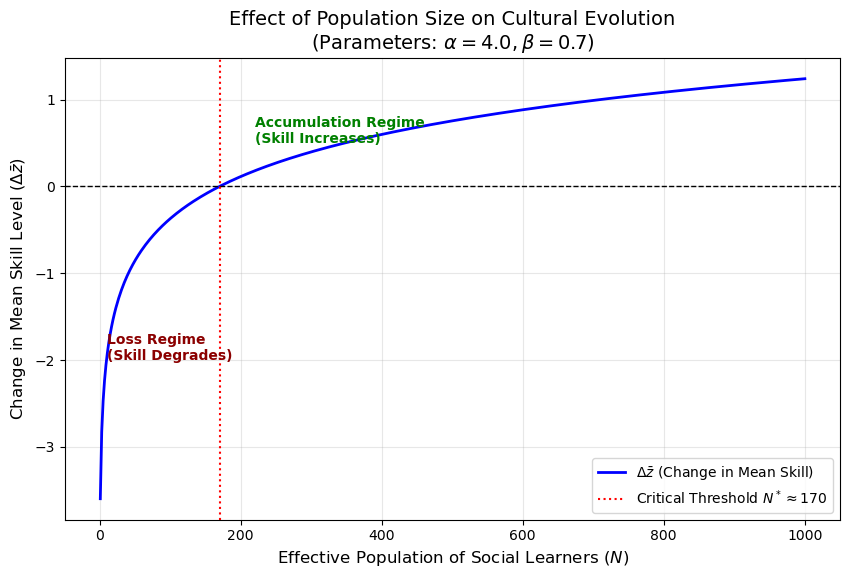

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameter Setup
# These values are chosen to illustrate the effect, similar to those in the paper's theoretical discussion.
alpha = 4.0      # The cost of inaccurate imitation (tendency to lose skill)
beta = 0.7       # The spread/variability (potential for rare improvements)
euler_gamma = 0.57721 # Euler-Mascheroni constant

# 2. The Analytical Function
def change_in_skill(N, alpha, beta):
    """
    Calculates the expected change in mean skill (Delta z_bar)
    based on population size N.
    Equation: Delta z = -alpha + beta * (epsilon + ln(N))
    """
    return -alpha + beta * (euler_gamma + np.log(N))

# 3. Generate Data for Plotting
population_sizes = np.linspace(1, 1000, 500)
delta_z_values = change_in_skill(population_sizes, alpha, beta)

# Find the critical threshold (N*) where Delta z = 0
# 0 = -alpha + beta * (epsilon + ln(N*))
# alpha / beta = epsilon + ln(N*)
# ln(N*) = (alpha / beta) - epsilon
# N* = exp((alpha / beta) - epsilon)
critical_N = np.exp((alpha / beta) - euler_gamma)
print(f"Critical Population Threshold (N*): {critical_N:.2f}")

# 4. Plotting Figure 1: The Relationship between N and Skill Change
plt.figure(figsize=(10, 6))
plt.plot(population_sizes, delta_z_values, label=r'$\Delta \bar{z}$ (Change in Mean Skill)', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(critical_N, color='red', linestyle=':', label=fr'Critical Threshold $N^* \approx {int(critical_N)}$')

# Annotations
plt.text(critical_N + 50, 0.5, "Accumulation Regime\n(Skill Increases)", color='green', fontweight='bold')
plt.text(10, -2, "Loss Regime\n(Skill Degrades)", color='darkred', fontweight='bold')

plt.title(f"Effect of Population Size on Cultural Evolution\n(Parameters: $\\alpha={alpha}, \\beta={beta}$)", fontsize=14)
plt.xlabel("Effective Population of Social Learners ($N$)", fontsize=12)
plt.ylabel(r"Change in Mean Skill Level ($\Delta \bar{z}$)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## The Gumbel Distribution in Cultural Evolution

Henrich's model assumes that the skill levels of potential models (the people being copied) follow a **Gumbel distribution** (also known as the Type I Extreme Value Distribution).

### Why the Gumbel?
1. **Extreme Values:** In a population of $N$ learners, we are interested in the *best* performance (the maximum). The Gumbel distribution is the limiting distribution for the maximum of a set of samples from many common distributions (like the Normal or Exponential).
2. **Heavy Right Tail:** It allows for rare "innovations" or exceptionally high-skill individuals, even if the average skill is lower.
3. **Mathematical Tractability:** The expected value of the maximum of $N$ Gumbel-distributed variables has a simple closed-form expression: $E[Z_{max}] = \mu + \beta(\epsilon + \ln N)$, where $\mu$ is the location parameter and $\beta$ is the scale parameter.

In Henrich's model:
- The current skill level is the "location" ($\mu$).
- The "scale" ($\beta$) represents the potential for improvement (the "spread" of talent).
- The "cost" ($\alpha$) is the shift in the mean during transmission.


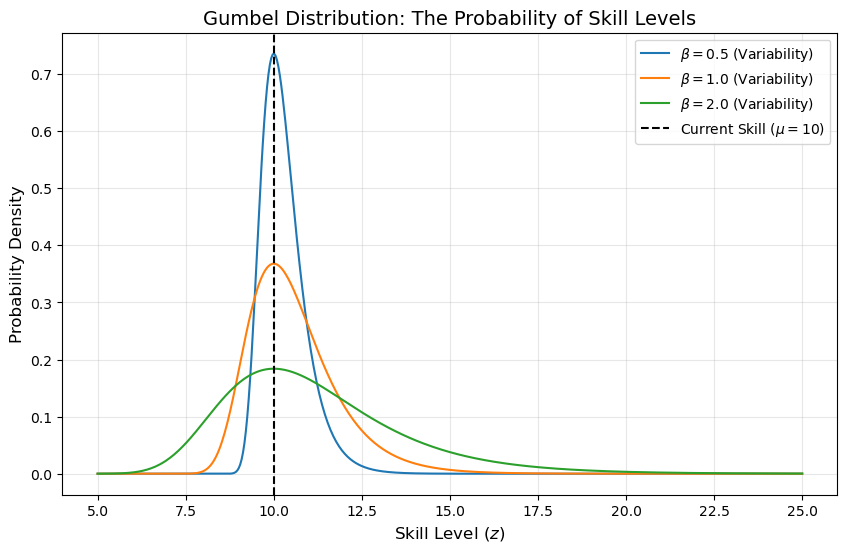

In [ ]:
from scipy.stats import gumbel_r

# Parameters to visualize
betas = [0.5, 1.0, 2.0]
mu = 10  # Current skill level (location parameter)

x = np.linspace(5, 25, 500)

plt.figure(figsize=(10, 6))
for b in betas:
    pdf = gumbel_r.pdf(x, loc=mu, scale=b)
    plt.plot(x, pdf, label=fr'$\beta = {b}$ (Variability)')

plt.title("Gumbel Distribution: The Probability of Skill Levels", fontsize=14)
plt.xlabel("Skill Level ($z$)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.axvline(mu, color='black', linestyle='--', label=f'Current Skill ($\mu = {mu}$)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
